<a href="https://colab.research.google.com/github/Victand/api_purchase_predict/blob/staging/InstantMesh_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
%cd /content
!GIT_LFS_SKIP_SMUDGE=1 git clone -b dev https://github.com/camenduru/InstantMesh
%cd /content/InstantMesh

!pip install pytorch-lightning==2.1.2 gradio==3.50.2 einops omegaconf torchmetrics webdataset accelerate tensorboard
!pip install PyMCubes trimesh rembg transformers diffusers==0.20.2 bitsandbytes imageio[ffmpeg] xatlas plyfile
!pip install jax==0.4.19 jaxlib==0.4.19 ninja

/content
fatal: destination path 'InstantMesh' already exists and is not an empty directory.
/content/InstantMesh
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pillow-10.4.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached pillow-10.4.0-cp312-cp312-manylinux_2_28_x86_64.whl (4.5 MB)
  Attempting uninstall: pillow
    Found existing installation: pillow 12.2.0
    Uninstalling pillow-12.2.0:
      Successfully uninstalled pillow-12.2.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rembg 2.0.75 requires numpy<3.0.0,>=2.3.0, but you

  Using cached diffusers-0.20.2-py3-none-any.whl
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (7.1 MB)
  Attempting uninstall: Pillow
    Found existing installation: pillow 10.4.0
    Uninstalling pillow-10.4.0:
      Successfully uninstalled pillow-10.4.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.38.0
    Uninstalling diffusers-0.38.0:
      Successfully uninstalled diffusers-0.38.0
ERROR: pip's dependency resolver does not currently take into account all t

  Cloning https://github.com/NVlabs/nvdiffrast to /tmp/pip-req-build-makyl8wl
  Running command git clone --filter=blob:none --quiet https://github.com/NVlabs/nvdiffrast /tmp/pip-req-build-makyl8wl
  Resolved https://github.com/NVlabs/nvdiffrast to commit 253ac4fcea7de5f396371124af597e6cc957bfae
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
# 1. On définit les chemins vers CUDA manuellement pour que le compilateur ne se perde pas
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda'
os.environ['PATH'] += ':/usr/local/cuda/bin'
os.environ['LD_LIBRARY_PATH'] += ':/usr/local/cuda/lib64'

# 2. On installe une dépendance souvent manquante qui bloque la création de la "roue" (wheel)
!pip install ninja

# 3. On tente l'installation de nvdiffrast en ignorant les erreurs de "PEP 517"
%cd /content/nvdiffrast
!pip install --no-build-isolation -e .

# 4. On revient dans le dossier du projet
%cd /content/InstantMesh



In [1]:
!pip install onnxruntime-gpu rembg

In [3]:
# On installe le trio magique qui s'accorde bien
!pip install huggingface_hub==0.23.2 diffusers==0.27.2 transformers==4.41.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 115.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.14.0
    Uninstalling huggingface_hub-1.14.0:
      Successfully uninstalled huggingface_hub-1.14.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.2
    Uninstalling tokenizers-0.15.2:
      Successfully uninstalled tokenizers-0.15.2
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.38.0
    Uninstalling diffusers-0.38.0:
      Successfully uninstalled diffusers-0.38.0
  Attempting uninstall: transformers
    Found existing installation: transfo

In [2]:
!pip install -U "huggingface-hub<1.0" "transformers>=4.41.0" "diffusers>=0.27.0"

  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached diffusers-0.38.0-py3-none-any.whl.metadata (20 kB)
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 101.5 MB/s eta 0:00:00
Using cached diffusers-0.38.0-py3-none-any.whl (5.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/content/InstantMesh


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/8 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 0
INFO:lightning_fabric.utilities.seed:Seed set to 42


  0%|          | 0/75 [00:00<?, ?it/s]

/tmp/ipykernel_11437/3179934067.py:41: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  show_image = torch.from_numpy(show_image)     # (960, 640, 3)


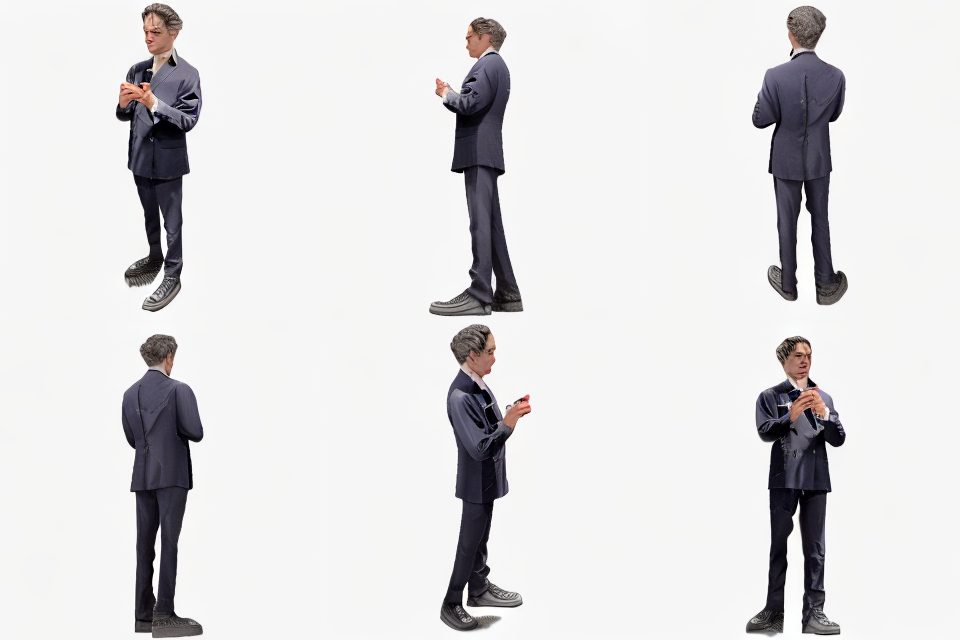

In [1]:
%cd /content/InstantMesh

import torch
model = None
torch.cuda.empty_cache()

import numpy as np
import rembg
from PIL import Image
from pytorch_lightning import seed_everything
from einops import rearrange
from diffusers import DiffusionPipeline, EulerAncestralDiscreteScheduler
from huggingface_hub import hf_hub_download
from src.utils.infer_util import remove_background, resize_foreground

pipeline = DiffusionPipeline.from_pretrained("sudo-ai/zero123plus-v1.2", custom_pipeline="zero123plus", torch_dtype=torch.float16, trust_remote_code=True)
pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(pipeline.scheduler.config, timestep_spacing='trailing')
unet_ckpt_path = hf_hub_download(repo_id="TencentARC/InstantMesh", filename="diffusion_pytorch_model.bin", repo_type="model")
state_dict = torch.load(unet_ckpt_path, map_location='cpu')
pipeline.unet.load_state_dict(state_dict, strict=True)
device = torch.device('cuda')
pipeline = pipeline.to(device)
seed_everything(0)

def preprocess(input_image, do_remove_background):
    rembg_session = rembg.new_session() if do_remove_background else None
    if do_remove_background:
        input_image = remove_background(input_image, rembg_session)
        input_image = resize_foreground(input_image, 0.85)
    return input_image

def generate_mvs(input_image, sample_steps, sample_seed):
    seed_everything(sample_seed)
    generator = torch.Generator(device=device)
    z123_image = pipeline(
        input_image,
        num_inference_steps=sample_steps,
        generator=generator,
    ).images[0]
    show_image = np.asarray(z123_image, dtype=np.uint8)
    show_image = torch.from_numpy(show_image)     # (960, 640, 3)
    show_image = rearrange(show_image, '(n h) (m w) c -> (n m) h w c', n=3, m=2)
    show_image = rearrange(show_image, '(n m) h w c -> (n h) (m w) c', n=2, m=3)
    show_image = Image.fromarray(show_image.numpy())
    return z123_image, show_image

input_image_path = '/content/InstantMesh/examples/IMG_4012.jpeg' #@param {type:"string"}
input_image = Image.open(input_image_path)
processed_image = preprocess(input_image, True)
processed_image
mv_images, mv_show_images = generate_mvs(processed_image, 75, 42)
mv_images.save('/content/InstantMesh/mv_images.png')
mv_show_images

  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (180 kB)
/content/nvdiffrast
Obtaining file:///content/nvdiffrast
  Checking if build backend supports build_editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for nvdiffrast (pyproject.toml) ... done
  Created wheel for nvdiffrast: filename=nvdiffrast-0.4.0-0.editable-cp312-cp312-linux_x86_64.whl size=6038 sha256=2169b94c567453cc1369dcdffa6fa8650b11108dbcc37262aedf3bb62d4f7dfa
  Stored in directory: /tmp/pip-ephem-wheel-cache-wl6utf66/wheels/f2/5a/7a/2afea8427a288126077a611bbbd6e1ea5bfb096ebb5467499b
Successfully built nvdiffrast
/content/InstantMesh


Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@32693085979a.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 13.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.14.0
    Uninstalling huggingface_hub-1.14.0:
      Successfully uninstalled huggingface_hub-1.14.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the fol

In [2]:
%cd /content/InstantMesh

import torch
pipeline = None
torch.cuda.empty_cache()

import os
from torchvision.transforms import v2
from huggingface_hub import hf_hub_download
from omegaconf import OmegaConf
from PIL import Image
import numpy as np
from einops import rearrange, repeat
import tempfile
from tqdm import tqdm
import imageio

from src.utils.train_util import instantiate_from_config
from src.utils.camera_util import (FOV_to_intrinsics, get_zero123plus_input_cameras,get_circular_camera_poses,)
from src.utils.mesh_util import save_obj, save_obj_with_mtl

config_path = 'configs/instant-mesh-base.yaml'
config = OmegaConf.load(config_path)
config_name = os.path.basename(config_path).replace('.yaml', '')
model_config = config.model_config
infer_config = config.infer_config
model_ckpt_path = hf_hub_download(repo_id="TencentARC/InstantMesh", filename="instant_mesh_base.ckpt", repo_type="model")
model = instantiate_from_config(model_config)
state_dict = torch.load(model_ckpt_path, map_location='cpu')['state_dict']
state_dict = {k[14:]: v for k, v in state_dict.items() if k.startswith('lrm_generator.') and 'source_camera' not in k}
model.load_state_dict(state_dict, strict=True)
device = torch.device('cuda')
model = model.to(device)
IS_FLEXICUBES = True if config_name.startswith('instant-mesh') else False
if IS_FLEXICUBES:
    model.init_flexicubes_geometry(device, fovy=30.0)
model = model.eval()

def images_to_video(images, output_path, fps=30):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    frames = []
    for i in range(images.shape[0]):
        frame = (images[i].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8).clip(0, 255)
        assert frame.shape[0] == images.shape[2] and frame.shape[1] == images.shape[3], \
            f"Frame shape mismatch: {frame.shape} vs {images.shape}"
        assert frame.min() >= 0 and frame.max() <= 255, \
            f"Frame value out of range: {frame.min()} ~ {frame.max()}"
        frames.append(frame)
    imageio.mimwrite(output_path, np.stack(frames), fps=fps, codec='h264')

def get_render_cameras(batch_size=1, M=120, radius=2.5, elevation=10.0, is_flexicubes=False):
    c2ws = get_circular_camera_poses(M=M, radius=radius, elevation=elevation)
    if is_flexicubes:
        cameras = torch.linalg.inv(c2ws)
        cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1, 1)
    else:
        extrinsics = c2ws.flatten(-2)
        intrinsics = FOV_to_intrinsics(30.0).unsqueeze(0).repeat(M, 1, 1).float().flatten(-2)
        cameras = torch.cat([extrinsics, intrinsics], dim=-1)
        cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1)
    return cameras

def make_mesh(mesh_fpath, planes):
    mesh_basename = os.path.basename(mesh_fpath).split('.')[0]
    mesh_dirname = os.path.dirname(mesh_fpath)
    mesh_vis_fpath = os.path.join(mesh_dirname, f"{mesh_basename}.glb")
    with torch.no_grad():
        mesh_out = model.extract_mesh(planes, use_texture_map=True, **infer_config,)
        vertices, faces, uvs, mesh_tex_idx, tex_map = mesh_out
        # vertices = vertices[:, [1, 2, 0]]
        # vertices[:, -1] *= -1
        # faces = faces[:, [2, 1, 0]]
        save_obj_with_mtl(
            vertices.data.cpu().numpy(),
            uvs.data.cpu().numpy(),
            faces.data.cpu().numpy(),
            mesh_tex_idx.data.cpu().numpy(),
            tex_map.permute(1, 2, 0).data.cpu().numpy(),
            mesh_fpath,
        )
        print(f"Mesh with texmap saved to {mesh_fpath}")
        # vertices, faces, vertex_colors = mesh_out
        # vertices = vertices[:, [1, 2, 0]]
        # vertices[:, -1] *= -1
        # faces = faces[:, [2, 1, 0]]
        # save_obj(vertices, faces, vertex_colors, mesh_fpath)
        # print(f"Mesh saved to {mesh_fpath}")
    return mesh_fpath

def make3d(images):
    images = np.asarray(images, dtype=np.float32) / 255.0
    images = torch.from_numpy(images).permute(2, 0, 1).contiguous().float()     # (3, 960, 640)
    images = rearrange(images, 'c (n h) (m w) -> (n m) c h w', n=3, m=2)        # (6, 3, 320, 320)
    input_cameras = get_zero123plus_input_cameras(batch_size=1, radius=4.0).to(device)
    render_cameras = get_render_cameras(
        batch_size=1, radius=4.5, elevation=20.0, is_flexicubes=IS_FLEXICUBES).to(device)
    images = images.unsqueeze(0).to(device)
    images = v2.functional.resize(images, (320, 320), interpolation=3, antialias=True).clamp(0, 1)
    directory = '/content/tmp'
    if not os.path.exists(directory):
        os.makedirs(directory)
    tempfile.tempdir = directory
    mesh_fpath = tempfile.NamedTemporaryFile(suffix=f".obj", delete=False).name
    print(mesh_fpath)
    mesh_basename = os.path.basename(mesh_fpath).split('.')[0]
    mesh_dirname = os.path.dirname(mesh_fpath)
    video_fpath = os.path.join(mesh_dirname, f"{mesh_basename}.mp4")
    with torch.no_grad():
        planes = model.forward_planes(images, input_cameras)
        chunk_size = 20 if IS_FLEXICUBES else 1
        render_size = 384
        frames = []
        for i in tqdm(range(0, render_cameras.shape[1], chunk_size)):
            if IS_FLEXICUBES:
                frame = model.forward_geometry(planes, render_cameras[:, i:i+chunk_size], render_size=render_size,)['img']
            else:
                frame = model.synthesizer(planes, cameras=render_cameras[:, i:i+chunk_size],render_size=render_size,)['images_rgb']
            frames.append(frame)
        frames = torch.cat(frames, dim=1)
        images_to_video(frames[0], video_fpath, fps=30,)
        print(f"Video saved to {video_fpath}")
    mesh_fpath = make_mesh(mesh_fpath, planes)
    return video_fpath, mesh_fpath

mv_images = Image.open('/content/InstantMesh/mv_images.png')
output_video, output_model_obj = make3d(mv_images)
!cp -f {output_video} /content/InstantMesh/output_video.mp4
!cp -f {output_model_obj} /content/InstantMesh/output_model.obj
from IPython.display import Video
Video(output_video, embed=True)

/content/InstantMesh


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at facebook/dino-vitb16 and are newly initialized: ['encoder.layer.0.adaLN_modulation.1.bias', 'encoder.layer.0.adaLN_modulation.1.weight', 'encoder.layer.1.adaLN_modulation.1.bias', 'encoder.layer.1.adaLN_modulation.1.weight', 'encoder.layer.10.adaLN_modulation.1.bias', 'encoder.layer.10.adaLN_modulation.1.weight', 'encoder.layer.11.adaLN_modulation.1.bias', 'encoder.layer.11.adaLN_modulation.1.weight', 'encoder.layer.2.adaLN_modulation.1.bias', 'encoder.layer.2.adaLN_modulation.1.weight', 'encoder.layer.3.adaLN_modulation.1.bias', 'encoder.layer.3.adaLN_modulation.1.weight', 'encoder.layer.4.adaLN_modulation.1.bias', 'encoder.layer.4.adaLN_modulation.1.weight', 'encoder.layer.5.adaLN_modulation.1.bias', 'encoder.layer.5.adaLN_modulation.1.weight', 'encoder.layer.6.adaLN_modulation.1.bias', 'encoder.layer.6.adaLN_modulation.1.weight', 'encoder.layer.7.adaLN_modulation.1.bias', 'encoder.layer.7.adaLN_modulation.1.w

/content/tmp/tmp_jx99pae.obj


  0%|          | 0/6 [00:00<?, ?it/s]/content/InstantMesh/src/models/geometry/render/neural_render.py:51: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  face_normals = torch.cross(v1 - v0, v2 - v0)
100%|██████████| 6/6 [00:04<00:00,  1.38it/s]


Video saved to /content/tmp/tmp_jx99pae.mp4
Mesh with texmap saved to /content/tmp/tmp_jx99pae.obj
